In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

EDF_FOLDER = "/content/drive/MyDrive/EEGproj/chb04"

print(os.listdir(EDF_FOLDER))

['chb04-summary.txt', 'chb04_05.edf.seizures', 'chb04_08.edf.seizures', 'chb04_03.edf', 'chb04_02.edf', 'chb04_01.edf', 'chb04_04.edf', 'chb04_05.edf', 'chb04_08.edf']


In [ ]:
!pip install mne

Loading EDF file into memory...
Extracting EDF parameters from /content/drive/MyDrive/EEGproj/chb04/chb04_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3686399  =      0.000 ... 14399.996 secs...


/tmp/ipykernel_6048/1615548418.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True)



     RECORDING METADATA     
Sampling Frequency : 256.0 Hz
Total Duration     : 14399.99609375 seconds (4.00 hours)
Total Channels     : 23
First 10 Channels  : ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4']

Filtering signal (Bandpass: 0.5–40 Hz | Notch: 60 Hz)...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
------------

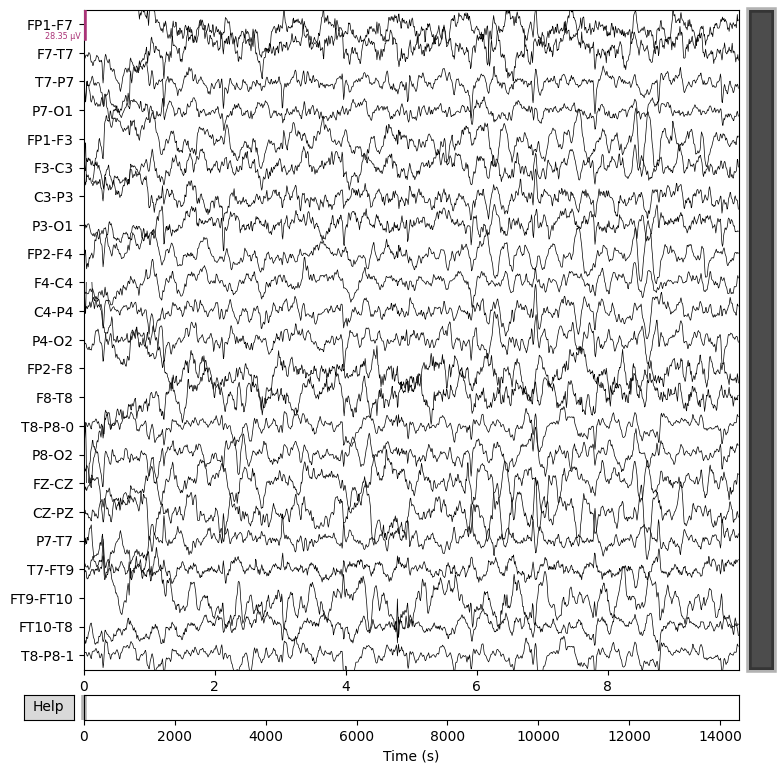

In [ ]:
import mne
import matplotlib.pyplot as plt

# 1. Path to your single .edf file (corrected folder name to 'EEGproj')
edf_path = "/content/drive/MyDrive/EEGproj/chb04/chb04_03.edf"

print("Loading EDF file into memory...")
# Read raw EDF file (preload=True loads the signal matrix into RAM)
raw = mne.io.read_raw_edf(edf_path, preload=True)

# 2. Inspect recording properties
print("\n" + "="*30)
print("     RECORDING METADATA     ")
print("="*30)
print(f"Sampling Frequency : {raw.info['sfreq']} Hz")
print(f"Total Duration     : {raw.times[-1]} seconds ({raw.times[-1]/3600:.2f} hours)")
print(f"Total Channels     : {len(raw.ch_names)}")
print("First 10 Channels  :", raw.ch_names[:10])

# 3. Clean up channel names (strips whitespace and standardizes to uppercase)
raw.rename_channels(lambda x: x.strip().upper())

# 4. Apply standard EEG filtering
print("\nFiltering signal (Bandpass: 0.5–40 Hz | Notch: 60 Hz)...")
raw.filter(l_freq=0.5, h_freq=40.0, fir_design='firwin')
raw.notch_filter(freqs=60.0)

# 5. Extract raw numerical matrix (Channels x Time Samples)
data, times = raw.get_data(return_times=True)
print(f"\nExtracted NumPy matrix shape: {data.shape}")
print(f"First channel amplitude range: [{data[0].min():.6f}, {data[0].max():.6f}]")

# 6. Plot interactive interactive EEG signal browser
print("\nOpening interactive plot window...")
raw.plot(duration=10, n_channels=23, scalings='auto', title="CHB04 Recording - MNE Browser")
plt.show()